<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Arabic_Readability_Classification_On_BAREC_Corpus_Using_Temp_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Arabic Readability Classification On BAREC Corpus Using Temp Model**


This notebook presents the implementation of Temp for Arabic readability classification using the BAREC Corpus.

The experiments use TF-IDF features extracted from Arabic text and evaluate the model under two readability classification schemes: 19-level and 5-level.

A baseline model is first established using the default hyperparameters, followed by hyperparameter tuning using GridSearchCV to identify the optimal regularization parameter.

Finally, the tuned model is evaluated with and without class balancing, and the performance of all models is compared using multiple evaluation metrics.

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [1]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [2]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

README.md:   0%|          | 0.00/6.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/dev-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.37MB            

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/54845 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/7310 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7286 [00:00<?, ? examples/s]

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [3]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [4]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [5]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [6]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0
Readability_Level_5,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [7]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [8]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [9]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


In [10]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

,count
Readability_Level_5,
1,13474
2,22383
3,18510
4,13234
5,1840


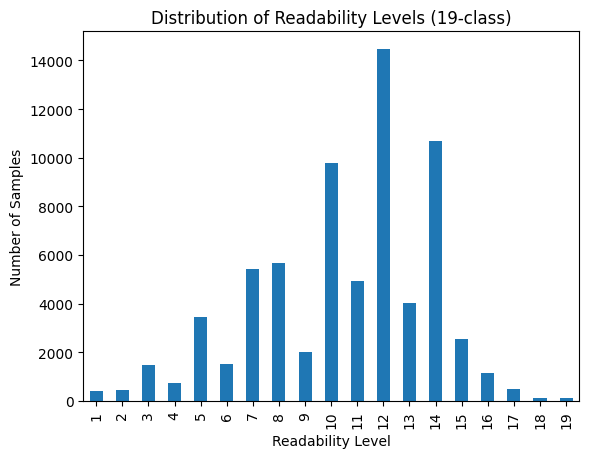

In [11]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

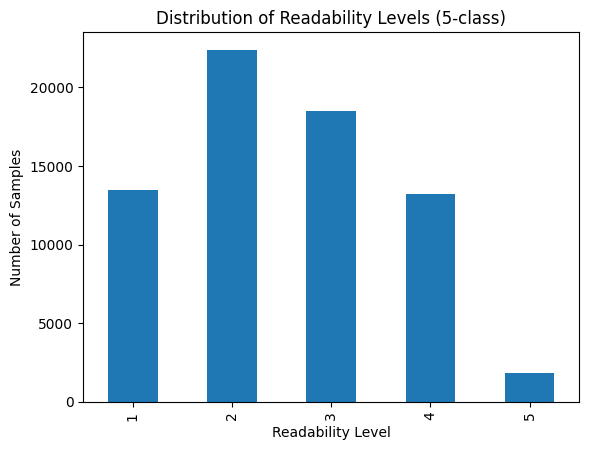

In [12]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

#**Model Training**

##**XGBoost Model**

**Why XGBoost?**

XGBoost was selected as the second machine learning model for this task to provide a meaningful methodological contrast with Random Forest. While Random Forest is a bagging ensemble that trains trees in parallel on bootstrap samples and averages their votes, XGBoost is a gradient boosting ensemble that trains trees sequentially, where each new tree corrects the residual errors of the previous ones. This sequential, error-correcting mechanism represents a fundamentally different ensemble strategy and is a well-established, widely-used alternative for tabular/sparse high-dimensional classification tasks such as TF-IDF-based text classification. It is worth noting that the original BAREC paper (Elmadani et al., 2025) evaluated only BERT-based transformer models (AraBERTv2, MARBERTv2, CamelBERT-msa) and did not include either Random Forest or XGBoost, so this comparison is a project-specific addition rather than a replication of a paper baseline.

This section first establishes an XGBoost **baseline model using the library's official default hyperparameters** (no tuning, no class balancing), to allow a direct, fair "before vs. after" comparison once hyperparameter tuning is introduced in the next step — mirroring the baseline-then-tuned structure used for the Random Forest model.

In [13]:
# Install and import XGBoost
!pip install xgboost -q

import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


##**ْXGboost Feature Extraction using TF-IDF**

The input text was converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) representation.

In [14]:
# Import TF-IDF vectorizer for converting text into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# Define input text and target labels
xgb_X_train = filtered_train_df["Word"]
xgb_X_dev = filtered_dev_df["Word"]
xgb_X_test = filtered_test_df["Word"]

# Create TF-IDF features using unigrams and bigrams
xgb_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

# Fit TF-IDF on the training set and transform all data splits
xgb_X_train_tfidf = xgb_vectorizer.fit_transform(xgb_X_train)
xgb_X_dev_tfidf = xgb_vectorizer.transform(xgb_X_dev)
xgb_X_test_tfidf = xgb_vectorizer.transform(xgb_X_test)

In [15]:
# XGBoost's multiclass objectives (multi:softmax / multi:softprob) require
# integer class labels in the range [0, num_class - 1].
# This is a documented library requirement (automatic label encoding was
# removed from XGBClassifier starting from version 1.6), NOT a modeling choice.
from sklearn.preprocessing import LabelEncoder

xgb_label_encoder = LabelEncoder()

xgb_y_train_19 = xgb_label_encoder.fit_transform(filtered_train_df["Readability_Level_19"])
xgb_y_dev_19 = xgb_label_encoder.transform(filtered_dev_df["Readability_Level_19"])
xgb_y_test_19 = xgb_label_encoder.transform(filtered_test_df["Readability_Level_19"])

print("Original label range:", filtered_train_df["Readability_Level_19"].min(),
      "to", filtered_train_df["Readability_Level_19"].max())
print("Encoded label range:", xgb_y_train_19.min(), "to", xgb_y_train_19.max())

Original label range: 1 to 19
Encoded label range: 0 to 18


**ngram_range Justification**


The parameter `ngram_range=(1,2)` was selected to include both **unigrams** (single words) and **bigrams** (pairs of consecutive words). While unigrams capture the importance of individual words, bigrams preserve short contextual information that may improve the model's ability to distinguish different readability levels.

This configuration is widely adopted in text classification tasks because it provides a good balance between capturing contextual information and maintaining computational efficiency.

---

##**Model Evaluation Function**

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy:** Measures exact match between predicted and true labels.
- **Acc ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

In [16]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    cohen_kappa_score,
    r2_score
)

import numpy as np


def evaluate_xgb_model(y_true, y_pred, dataset_name):
    """
    Evaluate a Linear SVM model using multiple classification metrics.
    """

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    adj_accuracy = np.mean(np.abs(y_true - y_pred) <= 1)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Print results
    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(f"Accuracy:                      {accuracy:.4f}")
    print(f"Adjacent Accuracy (±1):        {adj_accuracy:.4f}")
    print(f"Quadratic Weighted Kappa:      {qwk:.4f}")
    print(f"Macro F1-score:                {macro_f1:.4f}")
    print(f"Weighted Precision:            {precision:.4f}")
    print(f"Weighted Recall:               {recall:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"Root Mean Squared Error:       {rmse:.4f}")
    print(f"R² Score:                      {r2:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

**How to call the function?**

evaluate_temp_model(
    temp_y_test,
    temp_baseline_19_test_pred,
    "Baseline Temp (19-Level) - Test Set"
)

##**Confusion Matrix Function**

In [17]:
# Import libraries for confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Plot a confusion matrix for a classification model.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

**How to call the function?**

plot_confusion_matrix(
    temp_y_test,
    temp_baseline_19_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Baseline Temp(19-Level)"
)

---

##**XGboost Baseline Model (19-Level)**

In [18]:
from xgboost import XGBClassifier

# Baseline XGBoost model using library default hyperparameters.
# objective is set explicitly to multi:softprob because this is dictated by
# the task (multiclass with 19 classes), not an arbitrary choice —
# it matches what RF/SVM baselines already provide via predict_proba.
xgb_baseline_19 = XGBClassifier(
    objective="multi:softprob",
    random_state=42   # shared project-level value, consistent with RF/SVM
)

print(xgb_baseline_19.get_params())

{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [19]:
# Train the baseline model
xgb_baseline_19.fit(
    xgb_X_train_tfidf,
    xgb_y_train_19
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
# Generate predictions using the baseline xgb model
xgb_baseline_19_test_pred = xgb_baseline_19.predict(xgb_X_test_tfidf)

In [21]:

evaluate_xgb_model(
    xgb_label_encoder.inverse_transform(xgb_y_test_19),
    xgb_label_encoder.inverse_transform(xgb_baseline_19_test_pred),
    "Baseline XGBoost (19-Level) - Test Set"
)



Baseline XGBoost (19-Level) - Test Set
Accuracy:                      0.3446
Adjacent Accuracy (±1):        0.4591
Quadratic Weighted Kappa:      0.2854
Macro F1-score:                0.2324
Weighted Precision:            0.3589
Weighted Recall:               0.3446
Mean Absolute Error (MAE):     2.3994
Root Mean Squared Error:       3.5415
R² Score:                      -0.1802

Classification Report:

              precision    recall  f1-score   support

           1       0.78      0.22      0.34        32
           2       0.29      0.17      0.21        36
           3       0.38      0.20      0.26       141
           4       0.16      0.29      0.21        86
           5       0.47      0.36      0.41       380
           6       0.47      0.22      0.30       139
           7       0.40      0.41      0.40       585
           8       0.28      0.43      0.34       541
           9       0.49      0.39      0.44       190
          10       0.35      0.63      0.45      101

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

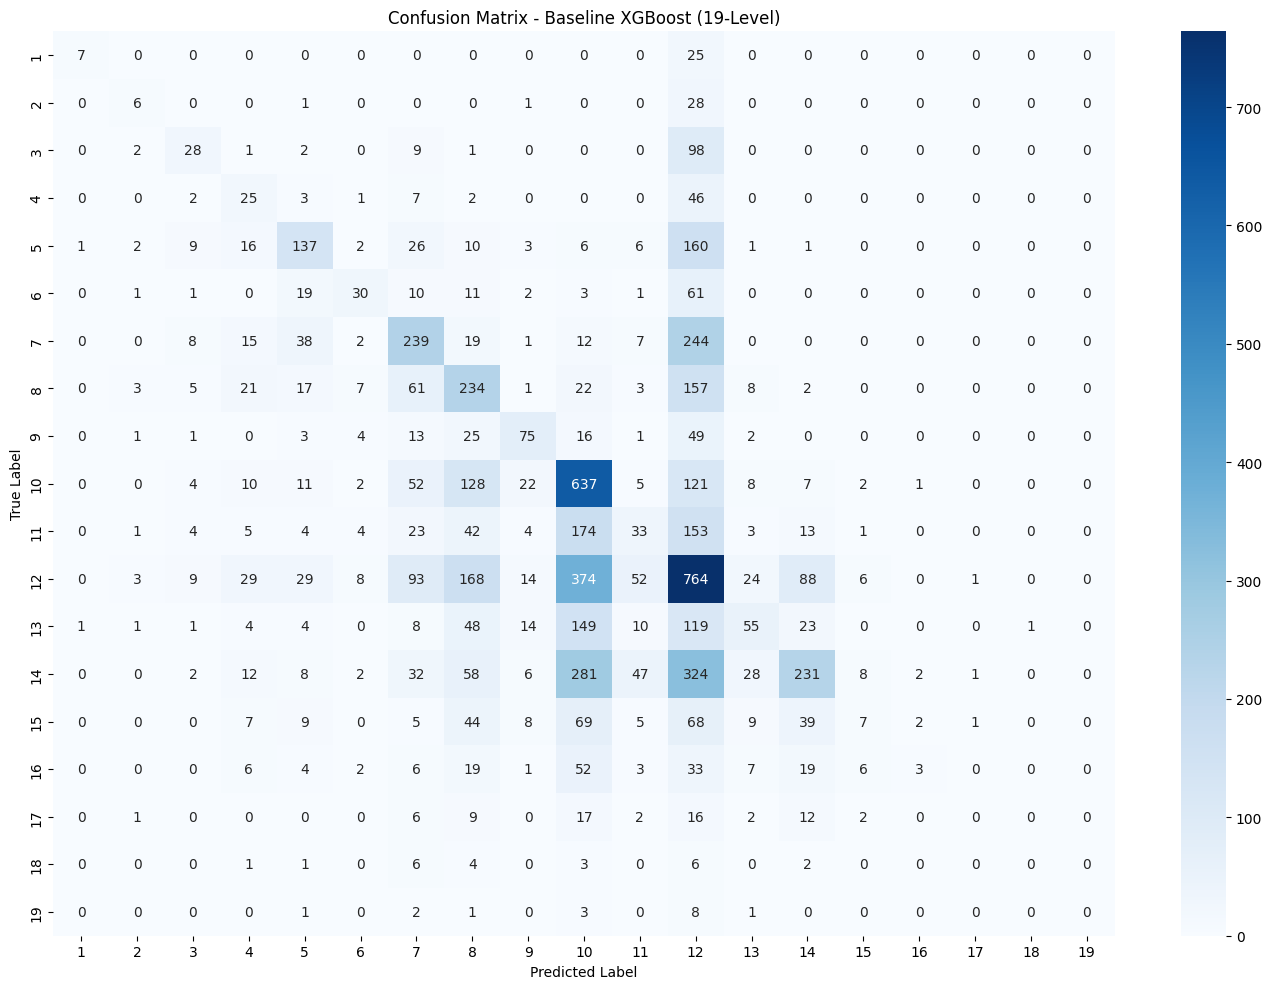

In [ ]:
plot_confusion_matrix(
    xgb_label_encoder.inverse_transform(xgb_y_test_19),
    xgb_label_encoder.inverse_transform(xgb_baseline_19_test_pred),
    labels=list(range(1, 20)),
    title="Confusion Matrix - Baseline XGBoost (19-Level)"
)

###**Temp Baseline Findings (19-Level)**


##**XGBoost Hyperparameter Tuning Using GridSearchCV (19-Level)**

**Hyperparameter Search Space Justification**

The hyperparameter search space was selected based on official XGBoost documentation
and prior research on closely related tasks, rather than arbitrary choices.

**n_estimators** and **learning_rate** were tuned because they jointly control the
boosting process: n_estimators sets how many sequential trees are added, and
learning_rate controls each tree's contribution to the final prediction.

The search space was defined as follows:

- n_estimators = [100, 200, 300]
- learning_rate = [0.03, 0.1, 0.3]

For **n_estimators**, 100 is the official XGBoost default and is also the value
implicitly used by Lee et al. (2021), who applied XGBoost to text readability
assessment — closely related to our task — and reported that "the other parameters
best performed at default," meaning they did not raise n_estimators above 100.
Following the supervisor's guidance to keep n_estimators low, the upper bound was
set to 300 (not 600), with 200 as a midpoint.

For **learning_rate**, 0.3 is the official XGBoost default (`eta`), while 0.03 is
the value used by Alzu'bi and Reynolds (2026) on a closely related Arabic
readability task. 0.1 was included as a midpoint between the two.

**max_depth was fixed at 6** (not searched) because this value is independently
supported by both the official XGBoost default and Alzu'bi and Reynolds (2026).

**Consistent with the team's SVM implementation, class weighting was NOT included
inside GridSearchCV.** The search identifies the best n_estimators/learning_rate
combination using the model's plain, unweighted behavior first. Class weighting
is evaluated afterward as a separate comparison (Balanced vs. None), exactly
mirroring the SVM Tuned Model (Balanced) / Tuned Model (None) structure, so that
the effect of class weighting can be isolated and compared independently of the
core hyperparameter search — the same rationale the team applied for SVM.

**Methodology (matches the team's SVM/RF implementation exactly):** Training and
Development sets are combined, and a `PredefinedSplit` fixes which samples are
used for training (-1) versus evaluation (0) within GridSearchCV — a single fit
per combination, scored on the Development set, with the Test set held out
entirely until final evaluation.

**Note on XGBoost's class-weighting mechanism:** XGBoost has no native
`class_weight` parameter for multiclass classification (unlike LinearSVC).
`sample_weight`, computed via `sklearn.utils.class_weight.compute_sample_weight`,
is the documented technical equivalent, serving the same purpose as SVM's
`class_weight` parameter.

**References**

XGBoost Developers. *XGBoost Parameters.* Official documentation.
https://xgboost.readthedocs.io/en/stable/parameter.html

Lee, B. W., Jang, Y. S., & Lee, J. (2021). Pushing on Text Readability Assessment:
A Transformer Meets Handcrafted Linguistic Features. *EMNLP 2021*, 10669–10686.

Alzu'bi, S., & Reynolds, R. (2026). Transformer-based readability classifiers are
worse than you think: Evidence from cross-domain Arabic readability assessment.
*BEA Workshop*, 766–776.

scikit-learn Developers. `sklearn.utils.class_weight.compute_sample_weight`.
Official documentation.

In [22]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBClassifier
from scipy.sparse import vstack
import numpy as np
import time

# learning_rate fixed at 0.3 — official XGBoost default, and empirically the
# best-performing value in our own preliminary GridSearchCV run
xgb_param_grid = {
    "n_estimators": [100, 200, 300]
}

FIXED_LEARNING_RATE = 0.3

# Full TF-IDF (matches SVM/RF exactly — no dimensionality reduction)
xgb_X_train_dev = vstack([
    xgb_X_train_tfidf,
    xgb_X_dev_tfidf
])
xgb_y_train_dev = np.concatenate([xgb_y_train_19, xgb_y_dev_19])

test_fold = np.concatenate([
    np.full(len(xgb_y_train_19), -1),
    np.zeros(len(xgb_y_dev_19))
])
predefined_split = PredefinedSplit(test_fold=test_fold)

# ---- Quick single-fit timing check BEFORE committing to the full grid ----
_t0 = time.time()
_probe = XGBClassifier(
    n_estimators=300, learning_rate=FIXED_LEARNING_RATE, max_depth=6,
    objective="multi:softprob", tree_method="hist",
    device="cuda",
    random_state=42
)
_probe.fit(xgb_X_train_tfidf, xgb_y_train_19)
_single = time.time() - _t0
print(f"Single fit (worst case, GPU) took {_single:.1f} sec")
print(f"Estimated total grid time (3 combos): ~{(_single*3)/3600:.2f} hours")

# ---- Full Grid Search — no class weighting, matches SVM exactly ----
xgb_grid_19 = GridSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        learning_rate=FIXED_LEARNING_RATE,
        random_state=42,
        max_depth=6,
        tree_method="hist",
        device="cuda"
    ),
    param_grid=xgb_param_grid,
    scoring="accuracy",
    cv=predefined_split,
    n_jobs=1,
    verbose=2
)

xgb_grid_19.fit(xgb_X_train_dev, xgb_y_train_dev)

print("Best Parameters:", xgb_grid_19.best_params_)
print(f"Best Development Accuracy: {xgb_grid_19.best_score_:.4f}")

Single fit (worst case, GPU) took 564.8 sec
Estimated total grid time (3 combos): ~0.47 hours
Fitting 1 folds for each of 3 candidates, totalling 3 fits


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [15:17:42] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END ...................................n_estimators=100; total time= 3.6min
[CV] END ...................................n_estimators=200; total time= 6.6min
[CV] END ...................................n_estimators=300; total time= 9.4min
Best Parameters: {'n_estimators': 300}
Best Development Accuracy: 0.3543


* **class_weight: Balanced**
##**XGBoost Tuned Model (19-Level)**
* **sample_weight: Balanced** (technical equivalent of SVM's class_weight — XGBoost has no native class_weight for multiclass)

In [23]:
from sklearn.utils.class_weight import compute_sample_weight

xgb_sample_weights_balanced = compute_sample_weight(class_weight="balanced", y=xgb_y_train_19)

# Create tuned XGBoost using the best n_estimators/learning_rate with balanced sample weights
xgb_tuned_19_balanced = XGBClassifier(
    n_estimators=xgb_grid_19.best_params_["n_estimators"],
    learning_rate=FIXED_LEARNING_RATE,
    max_depth=6,
    objective="multi:softprob",
    tree_method="hist",
    device="cuda",
    random_state=42
)

# Train the tuned model
xgb_tuned_19_balanced.fit(
    xgb_X_train_tfidf,
    xgb_y_train_19,
    sample_weight=xgb_sample_weights_balanced
)

# Generate predictions
xgb_tuned_19_balanced_test_pred = xgb_tuned_19_balanced.predict(xgb_X_test_tfidf)

In [24]:
evaluate_xgb_model(
    xgb_label_encoder.inverse_transform(xgb_y_test_19),
    xgb_label_encoder.inverse_transform(xgb_tuned_19_balanced_test_pred),
    "Tuned XGBoost (19-Level) - Balanced"
)

Tuned XGBoost (19-Level) - Balanced
Accuracy:                      0.2987
Adjacent Accuracy (±1):        0.4168
Quadratic Weighted Kappa:      0.4163
Macro F1-score:                0.2428
Weighted Precision:            0.3818
Weighted Recall:               0.2987
Mean Absolute Error (MAE):     2.8084
Root Mean Squared Error:       4.0520
R² Score:                      -0.5449

Classification Report:

              precision    recall  f1-score   support

           1       0.85      0.53      0.65        32
           2       0.25      0.36      0.30        36
           3       0.14      0.87      0.24       141
           4       0.11      0.60      0.18        86
           5       0.40      0.46      0.42       380
           6       0.20      0.37      0.26       139
           7       0.35      0.45      0.39       585
           8       0.25      0.46      0.32       541
           9       0.29      0.40      0.34       190
          10       0.36      0.56      0.44      1010
 

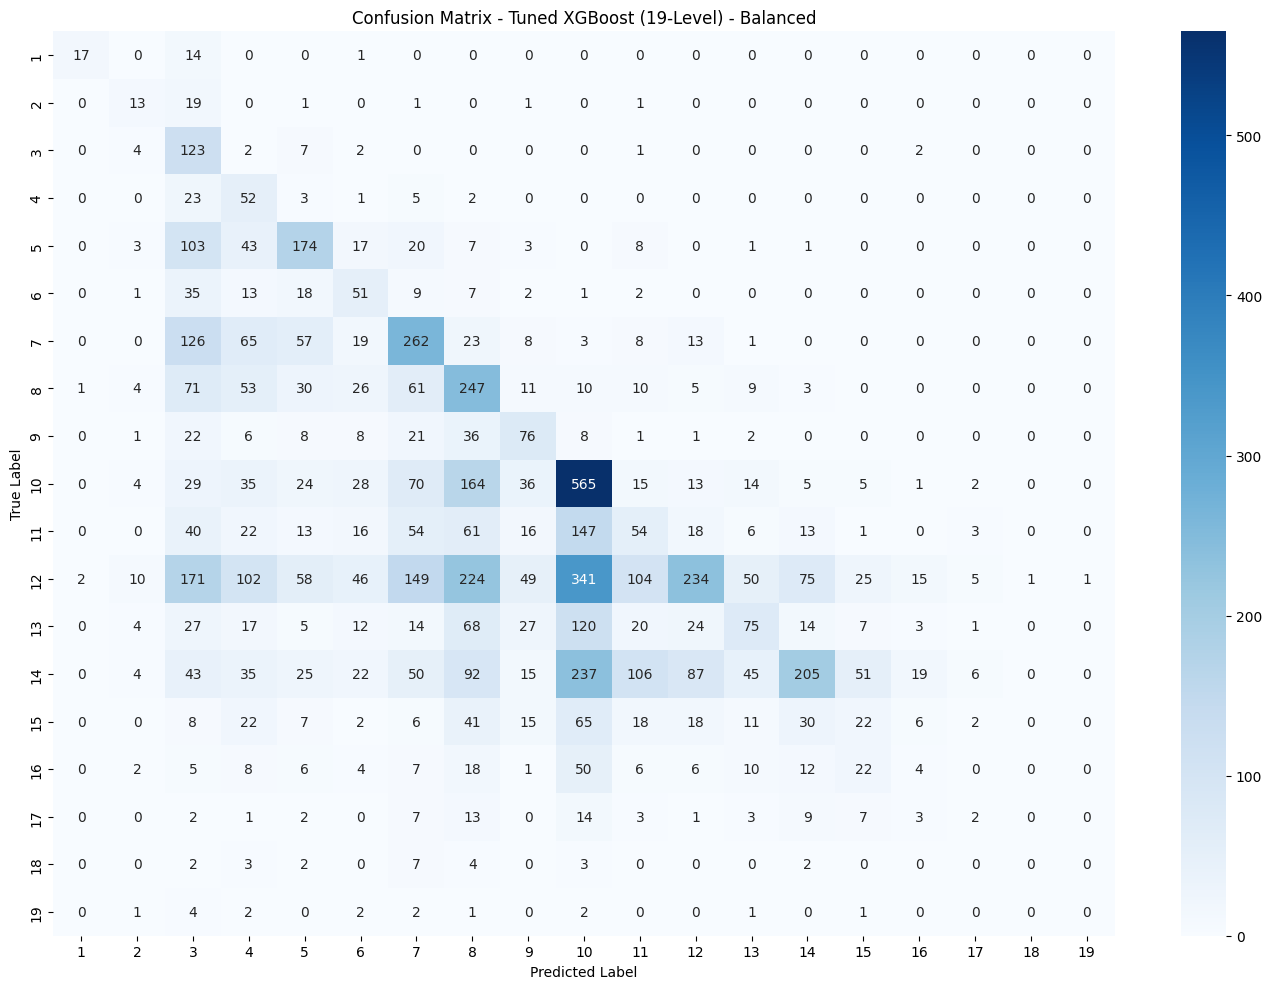

In [26]:
plot_confusion_matrix(
    xgb_label_encoder.inverse_transform(xgb_y_test_19),
    xgb_label_encoder.inverse_transform(xgb_tuned_19_balanced_test_pred),
    labels=list(range(1, 20)),
    title="Confusion Matrix - Tuned XGBoost (19-Level) - Balanced"
)

###**XGboost Tunned Findings (19-Level)**
The balanced tuned XGBoost model achieved an accuracy of 29.87% and an Adjacent
Accuracy (±1) of 41.68%, with a Quadratic Weighted Kappa of 0.4163, indicating
moderate agreement with the true labels when accounting for the ordinal nature
of the readability levels. However, the Macro F1-score (0.2428) is noticeably
lower than the Weighted F1, revealing that performance is uneven across classes:
minority levels such as 18 and 19 were not predicted correctly at all (F1 = 0.00),
while mid-frequency levels such as 10 and 12 were predicted far more often than
their true frequency, with level 10 in particular acting as a dominant "default"
prediction for many neighboring classes, as shown in the confusion matrix.
Despite applying balanced sample weighting to counter class imbalance, the model
still struggles to separate closely adjacent readability levels, which is
consistent with the general difficulty of fine-grained 19-level classification
observed across the team's other models.

..

##**Temp Tuned Model (19-Level)**
* **class_weight: None**

In [25]:
# Create tuned XGBoost using the best n_estimators/learning_rate without weighting
xgb_tuned_19_none = XGBClassifier(
    n_estimators=xgb_grid_19.best_params_["n_estimators"],
    learning_rate=FIXED_LEARNING_RATE,
    max_depth=6,
    objective="multi:softprob",
    tree_method="hist",
    device="cuda",
    random_state=42
)

# Train the tuned model
xgb_tuned_19_none.fit(
    xgb_X_train_tfidf,
    xgb_y_train_19
)

# Generate predictions
xgb_tuned_19_none_test_pred = xgb_tuned_19_none.predict(xgb_X_test_tfidf)

In [27]:
evaluate_xgb_model(
    xgb_label_encoder.inverse_transform(xgb_y_test_19),
    xgb_label_encoder.inverse_transform(xgb_tuned_19_none_test_pred),
    "Tuned XGBoost (19-Level) - None"
)

Tuned XGBoost (19-Level) - None
Accuracy:                      0.3507
Adjacent Accuracy (±1):        0.4614
Quadratic Weighted Kappa:      0.3372
Macro F1-score:                0.2393
Weighted Precision:            0.3581
Weighted Recall:               0.3507
Mean Absolute Error (MAE):     2.3898
Root Mean Squared Error:       3.5456
R² Score:                      -0.1829

Classification Report:

              precision    recall  f1-score   support

           1       0.78      0.22      0.34        32
           2       0.33      0.14      0.20        36
           3       0.30      0.28      0.29       141
           4       0.17      0.35      0.23        86
           5       0.43      0.43      0.43       380
           6       0.33      0.24      0.28       139
           7       0.38      0.48      0.43       585
           8       0.27      0.48      0.35       541
           9       0.46      0.39      0.42       190
          10       0.36      0.65      0.46      1010
     

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

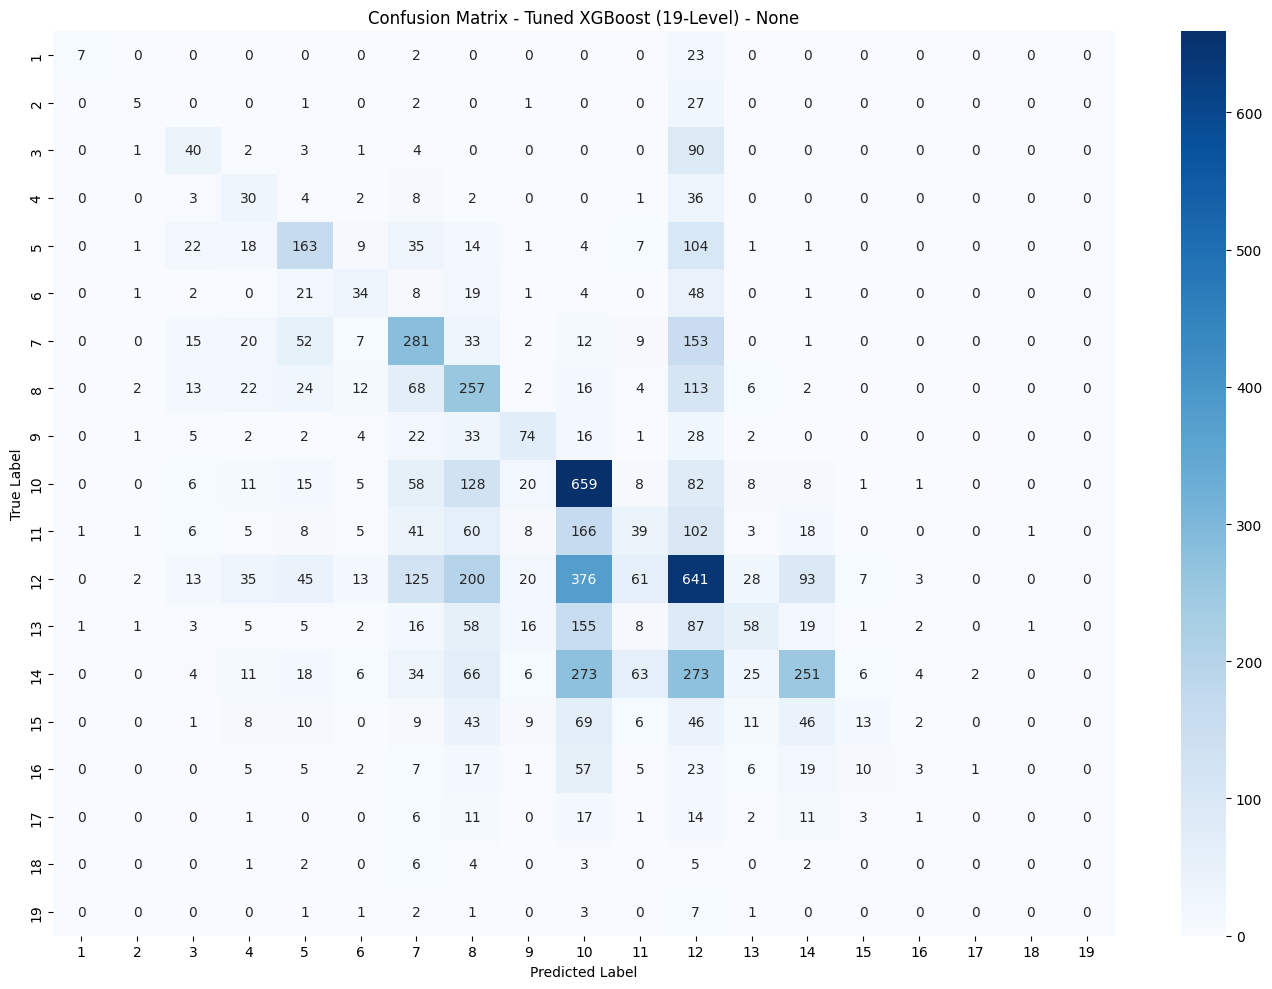

In [28]:
plot_confusion_matrix(
    xgb_label_encoder.inverse_transform(xgb_y_test_19),
    xgb_label_encoder.inverse_transform(xgb_tuned_19_none_test_pred),
    labels=list(range(1, 20)),
    title="Confusion Matrix - Tuned XGBoost (19-Level) - None"
)


###**XGBoost Tuned Findings (19-Level)**
* **sample_weight: None**

The unweighted tuned XGBoost model achieved an accuracy of 35.07%, outperforming
the balanced version (29.87%). It also achieved a higher Adjacent Accuracy (±1)
of 46.14% and a lower MAE (2.39 vs. 2.81), meaning predictions were generally
closer to the true readability level even when not exact. However, its Quadratic
Weighted Kappa (0.3372) was lower than the balanced model's (0.4163), suggesting
the balanced model agreed more with the ordinal structure of the labels despite
its lower raw accuracy. As with the balanced version, minority classes (17, 18, 19)
were still not predicted at all, and the model continues to over-predict the
frequent mid-range levels (10 and 12), as shown in the confusion matrix.

..

---

##**XGboost Baseline Model (5-Level)**

In [19]:
# Define target labels for the 5-level classification task
xgb_y_train_5_raw = filtered_train_df["Readability_Level_5"]
xgb_y_dev_5_raw = filtered_dev_df["Readability_Level_5"]
xgb_y_test_5_raw = filtered_test_df["Readability_Level_5"]

# Separate LabelEncoder for the 5-level task (independent from the 19-level encoder)
# Required because XGBoost's multiclass objective needs labels in [0, num_class-1]
from sklearn.preprocessing import LabelEncoder

xgb_label_encoder_5 = LabelEncoder()
xgb_y_train_5 = xgb_label_encoder_5.fit_transform(xgb_y_train_5_raw)
xgb_y_dev_5   = xgb_label_encoder_5.transform(xgb_y_dev_5_raw)
xgb_y_test_5  = xgb_label_encoder_5.transform(xgb_y_test_5_raw)

print("Encoded label range:", xgb_y_train_5.min(), "to", xgb_y_train_5.max())

Encoded label range: 0 to 4


In [20]:
from xgboost import XGBClassifier

# Baseline XGBoost model using library default hyperparameters (matches 19-level baseline)
xgb_baseline_5 = XGBClassifier(
    objective="multi:softprob",
    random_state=42
)

print(xgb_baseline_5.get_params())

{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [21]:
xgb_baseline_5.fit(
    xgb_X_train_tfidf,
    xgb_y_train_5
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
xgb_baseline_5_test_pred = xgb_baseline_5.predict(xgb_X_test_tfidf)

In [23]:
evaluate_xgb_model(
    xgb_label_encoder_5.inverse_transform(xgb_y_test_5),
    xgb_label_encoder_5.inverse_transform(xgb_baseline_5_test_pred),
    "Baseline XGBoost (5-Level) - Test Set"
)

Baseline XGBoost (5-Level) - Test Set
Accuracy:                      0.4688
Adjacent Accuracy (±1):        0.7556
Quadratic Weighted Kappa:      0.3393
Macro F1-score:                0.3408
Weighted Precision:            0.5090
Weighted Recall:               0.4688
Mean Absolute Error (MAE):     0.8434
Root Mean Squared Error:       1.2736
R² Score:                      -0.3402

Classification Report:

              precision    recall  f1-score   support

           1       0.45      0.94      0.61      1399
           2       0.44      0.68      0.54      2205
           3       0.58      0.18      0.28      2100
           4       0.64      0.17      0.27      1315
           5       0.17      0.00      0.01       267

    accuracy                           0.47      7286
   macro avg       0.46      0.39      0.34      7286
weighted avg       0.51      0.47      0.41      7286



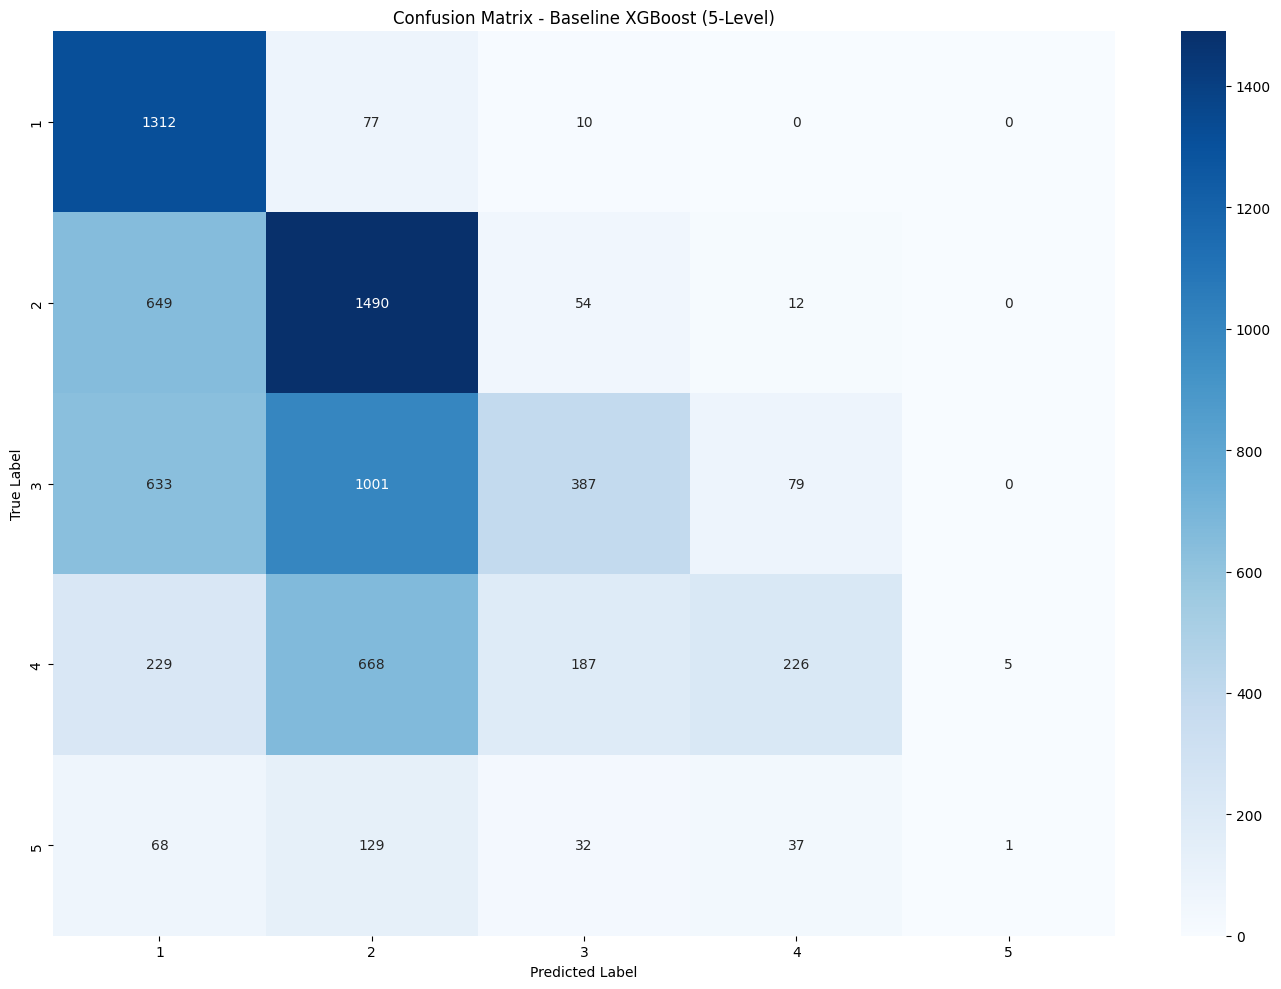

In [24]:
plot_confusion_matrix(
    xgb_label_encoder_5.inverse_transform(xgb_y_test_5),
    xgb_label_encoder_5.inverse_transform(xgb_baseline_5_test_pred),
    labels=list(range(1, 6)),
    title="Confusion Matrix - Baseline XGBoost (5-Level)"
)

###**XGBoost Baseline Findings (5-Level)**

The baseline XGBoost model achieved an accuracy of 46.88% and a high Adjacent
Accuracy (±1) of 75.56%, reflecting the coarser granularity of the 5-level task
compared to 19-level. However, the model struggled heavily with the minority
class (level 5), achieving only 1% recall, and QWK (0.3393) remained moderate,
indicating the class imbalance problem persists even at this coarser level.

##**XGBoost Hyperparameter Tuning Using GridSearchCV (5-Level)**

**Hyperparameter Search Space Justification**

The same search space and fixed parameters established for the 19-level task were
used here — n_estimators = [100, 200, 300], learning_rate fixed at 0.3, and
max_depth fixed at 6 — following the same principle applied by the team's SVM
implementation: using an identical search space across the 19-level and 5-level
tasks ensures a fair comparison between the two experimental settings, even though
the optimal combination is selected independently for each task using its own
predefined development set.

As with the 19-level task, class weighting was not included inside GridSearchCV;
it is evaluated afterward as a separate comparison (Balanced vs. None).

**References:** Same as the 19-level XGBoost tuning section (XGBoost official
documentation; Lee et al., 2021; Alzu'bi & Reynolds, 2026).

In [25]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBClassifier
from scipy.sparse import vstack
import numpy as np

xgb_param_grid_5 = {
    "n_estimators": [100, 200, 300]
}

FIXED_LEARNING_RATE = 0.3   # same fixed value as 19-level, for consistency

# Combine Training and Development features
xgb_X_train_dev_5 = vstack([
    xgb_X_train_tfidf,
    xgb_X_dev_tfidf
])

xgb_y_train_dev_5 = np.concatenate([
    xgb_y_train_5,
    xgb_y_dev_5
])

# Define the fixed split
# -1 = Training set
#  0 = Development set
test_fold_5 = np.concatenate([
    np.full(len(xgb_y_train_5), -1),
    np.zeros(len(xgb_y_dev_5))
])
predefined_split_5 = PredefinedSplit(test_fold=test_fold_5)

# Grid Search — no class weighting, matches SVM and XGBoost 19-level structure
xgb_grid_5 = GridSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        learning_rate=FIXED_LEARNING_RATE,
        random_state=42,
        max_depth=6,
        tree_method="hist",
        device="cuda"
    ),
    param_grid=xgb_param_grid_5,
    scoring="accuracy",
    cv=predefined_split_5,
    n_jobs=1,
    verbose=2
)

xgb_grid_5.fit(
    xgb_X_train_dev_5,
    xgb_y_train_dev_5
)

print("Best Parameters:", xgb_grid_5.best_params_)
print(f"Best Development Accuracy: {xgb_grid_5.best_score_:.4f}")

Fitting 1 folds for each of 3 candidates, totalling 3 fits


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [21:28:45] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END ...................................n_estimators=100; total time= 1.4min
[CV] END ...................................n_estimators=200; total time= 2.4min
[CV] END ...................................n_estimators=300; total time= 3.3min
Best Parameters: {'n_estimators': 300}
Best Development Accuracy: 0.5160


##**XGBoost Tuned Model (5-Level)**
* **sample_weight: Balanced**

In [26]:
from sklearn.utils.class_weight import compute_sample_weight

xgb_sample_weights_balanced_5 = compute_sample_weight(class_weight="balanced", y=xgb_y_train_5)

# Create tuned XGBoost using the best n_estimators with balanced sample weights
xgb_tuned_5_balanced = XGBClassifier(
    n_estimators=xgb_grid_5.best_params_["n_estimators"],
    learning_rate=FIXED_LEARNING_RATE,
    max_depth=6,
    objective="multi:softprob",
    tree_method="hist",
    device="cuda",
    random_state=42
)

# Train the tuned model
xgb_tuned_5_balanced.fit(
    xgb_X_train_tfidf,
    xgb_y_train_5,
    sample_weight=xgb_sample_weights_balanced_5
)

# Generate predictions
xgb_tuned_5_balanced_test_pred = xgb_tuned_5_balanced.predict(xgb_X_test_tfidf)

In [27]:
evaluate_xgb_model(
    xgb_label_encoder_5.inverse_transform(xgb_y_test_5),
    xgb_label_encoder_5.inverse_transform(xgb_tuned_5_balanced_test_pred),
    "Tuned XGBoost (5-Level) - Balanced"
)

Tuned XGBoost (5-Level) - Balanced
Accuracy:                      0.4822
Adjacent Accuracy (±1):        0.7652
Quadratic Weighted Kappa:      0.3907
Macro F1-score:                0.3761
Weighted Precision:            0.5172
Weighted Recall:               0.4822
Mean Absolute Error (MAE):     0.8228
Root Mean Squared Error:       1.2625
R² Score:                      -0.3169

Classification Report:

              precision    recall  f1-score   support

           1       0.43      0.96      0.60      1399
           2       0.48      0.61      0.54      2205
           3       0.60      0.21      0.31      2100
           4       0.62      0.28      0.39      1315
           5       0.11      0.03      0.04       267

    accuracy                           0.48      7286
   macro avg       0.45      0.42      0.38      7286
weighted avg       0.52      0.48      0.44      7286



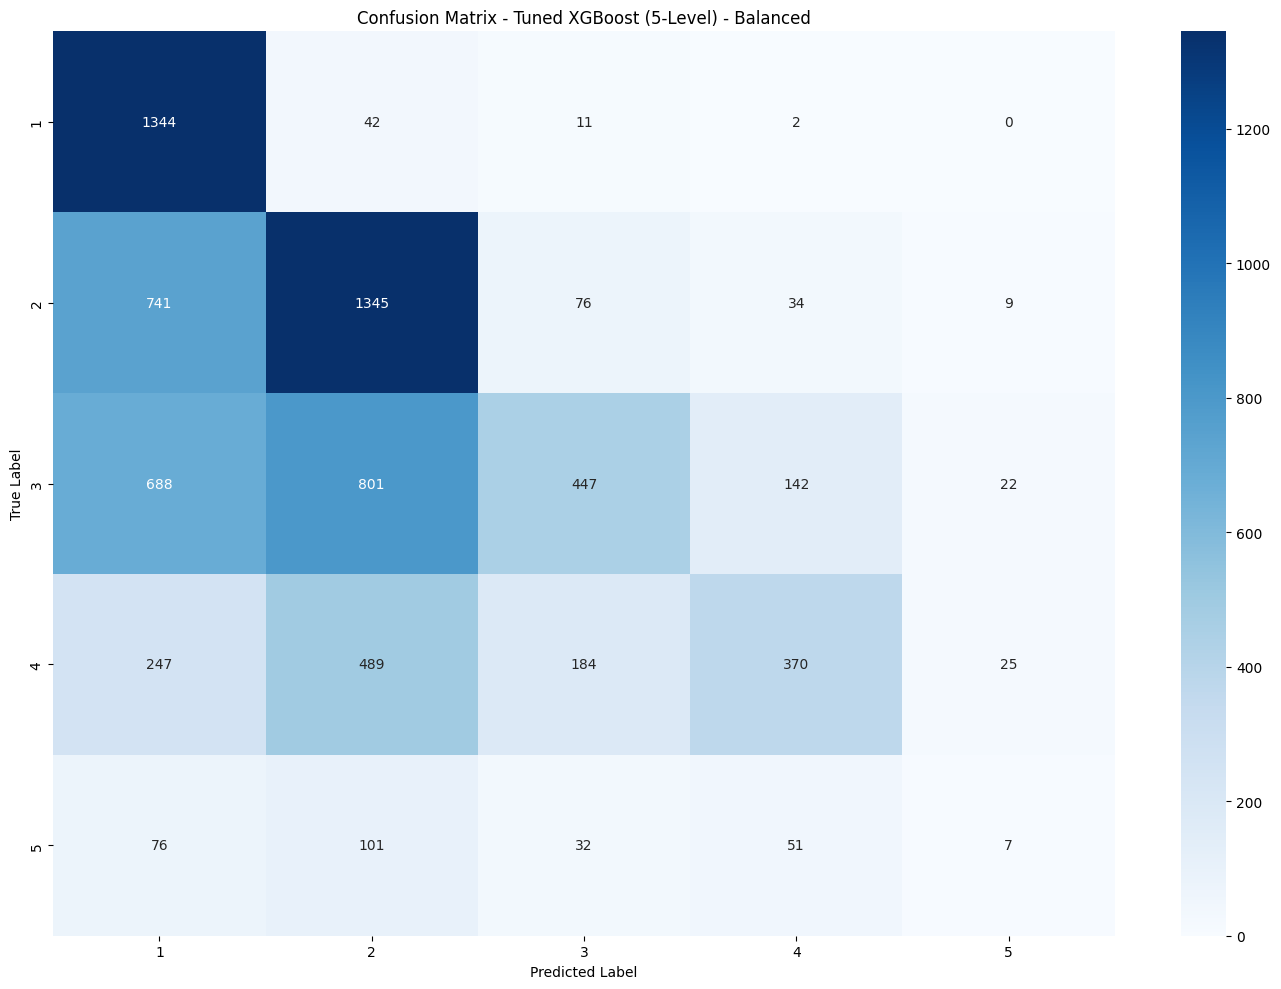

In [28]:
plot_confusion_matrix(
    xgb_label_encoder_5.inverse_transform(xgb_y_test_5),
    xgb_label_encoder_5.inverse_transform(xgb_tuned_5_balanced_test_pred),
    labels=list(range(1, 6)),
    title="Confusion Matrix - Tuned XGBoost (5-Level) - Balanced"
)

###**XGBoost Tuned Findings (5-Level)**
* **sample_weight: Balanced**

The balanced tuned model improved over the baseline across most metrics: accuracy
rose to 48.22%, QWK improved to 0.3907, and MAE dropped slightly to 0.8228. Class
5 recall improved marginally (from 0% to 3%), showing that balanced weighting
helped the model attend somewhat better to the minority class, though performance
on it remains very weak overall.

##**XGBoost Tuned Model (5-Level)**
* **sample_weight: None**

In [29]:
# Create tuned XGBoost using the best n_estimators without weighting
xgb_tuned_5_none = XGBClassifier(
    n_estimators=xgb_grid_5.best_params_["n_estimators"],
    learning_rate=FIXED_LEARNING_RATE,
    max_depth=6,
    objective="multi:softprob",
    tree_method="hist",
    device="cuda",
    random_state=42
)

# Train the tuned model
xgb_tuned_5_none.fit(
    xgb_X_train_tfidf,
    xgb_y_train_5
)

# Generate predictions
xgb_tuned_5_none_test_pred = xgb_tuned_5_none.predict(xgb_X_test_tfidf)

In [30]:
evaluate_xgb_model(
    xgb_label_encoder_5.inverse_transform(xgb_y_test_5),
    xgb_label_encoder_5.inverse_transform(xgb_tuned_5_none_test_pred),
    "Tuned XGBoost (5-Level) - None"
)

Tuned XGBoost (5-Level) - None
Accuracy:                      0.4946
Adjacent Accuracy (±1):        0.7756
Quadratic Weighted Kappa:      0.3759
Macro F1-score:                0.3701
Weighted Precision:            0.5297
Weighted Recall:               0.4946
Mean Absolute Error (MAE):     0.7910
Root Mean Squared Error:       1.2258
R² Score:                      -0.2413

Classification Report:

              precision    recall  f1-score   support

           1       0.48      0.92      0.63      1399
           2       0.46      0.71      0.56      2205
           3       0.58      0.22      0.32      2100
           4       0.65      0.21      0.32      1315
           5       0.33      0.01      0.01       267

    accuracy                           0.49      7286
   macro avg       0.50      0.41      0.37      7286
weighted avg       0.53      0.49      0.44      7286



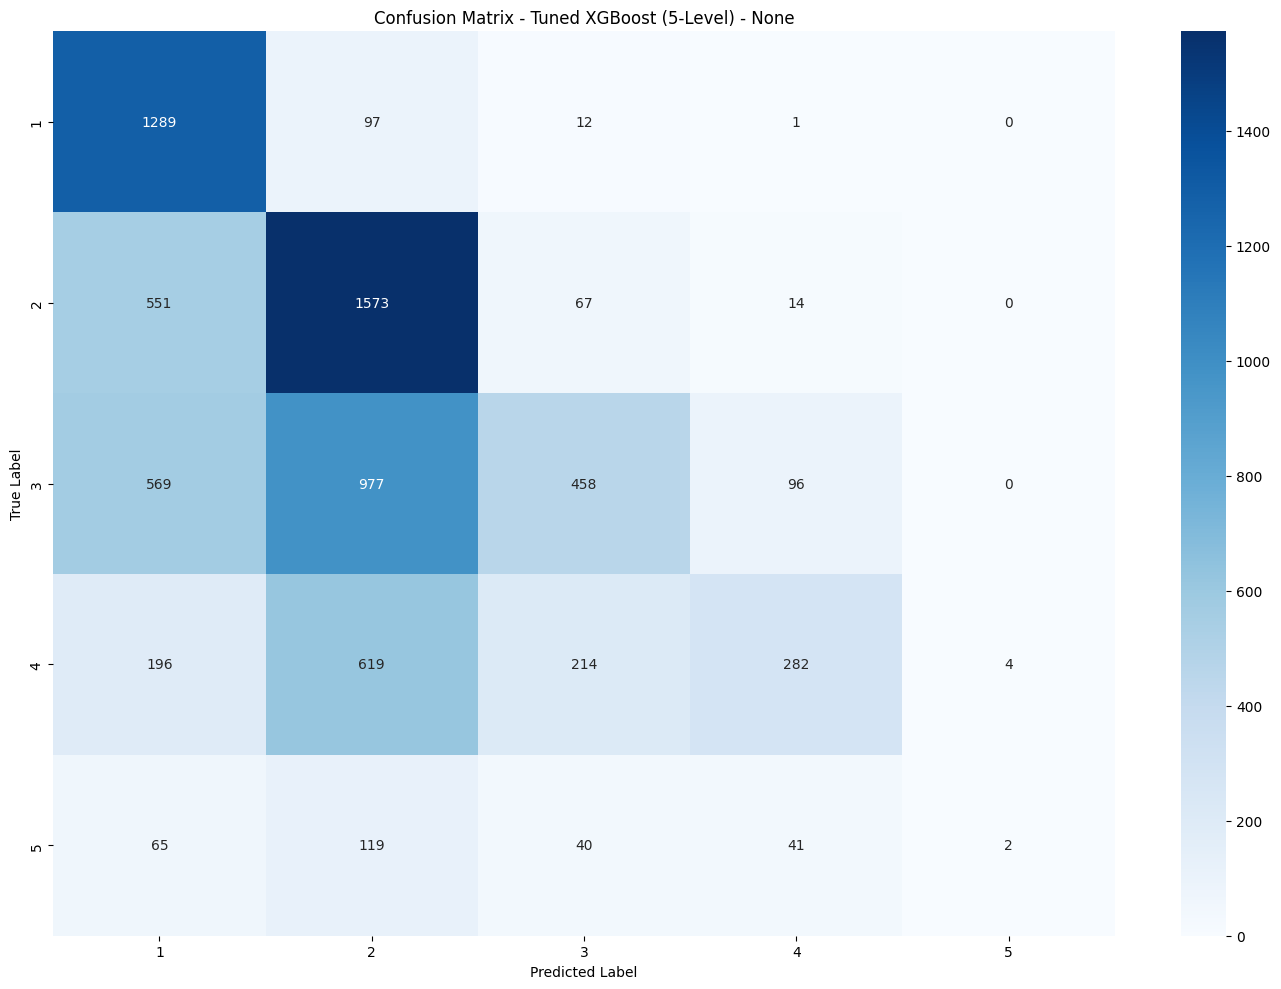

In [31]:
plot_confusion_matrix(
    xgb_label_encoder_5.inverse_transform(xgb_y_test_5),
    xgb_label_encoder_5.inverse_transform(xgb_tuned_5_none_test_pred),
    labels=list(range(1, 6)),
    title="Confusion Matrix - Tuned XGBoost (5-Level) - None"
)

###**XGBoost Tuned Findings (5-Level)**
* **sample_weight: None**

The unweighted tuned model achieved the best accuracy among all three 5-level
XGBoost models (49.46%) and the lowest MAE (0.7910), but its QWK (0.3759) was
slightly lower than the balanced version's (0.3907). This mirrors the same
accuracy-vs-QWK trade-off observed at the 19-level: removing class weighting
improves raw accuracy, while balanced weighting slightly improves agreement with
the ordinal label structure.


#**Comparison between 19 & 5 Level Results**


### XGBoost Model (19-Level)

| Model | Accuracy | Adjacent Accuracy (±1) | Quadratic Weighted Kappa | Macro F1-score | Weighted Precision | Weighted Recall | MAE | RMSE | R² Score |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **XGBoost Baseline Model** | 0.3446 | 0.4591 | 0.2854 | 0.2324 | 0.3589 | 0.3446 | 2.3994 | **3.5415** | **-0.1802** |
| **XGBoost Tuned Model (Balanced)** | 0.2987 | 0.4168 | **0.4163** | **0.2428** | **0.3818** | 0.2987 | 2.8084 | 4.0520 | -0.5449 |
| **XGBoost Tuned Model (None)** | **0.3507** | **0.4614** | 0.3372 | 0.2393 | 0.3581 | **0.3507** | **2.3898** | 3.5456 | -0.1829 |

<br>

### XGBoost Model (5-Level)

| Model | Accuracy | Adjacent Accuracy (±1) | Quadratic Weighted Kappa | Macro F1-score | Weighted Precision | Weighted Recall | MAE | RMSE | R² Score |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **XGBoost Baseline Model** | 0.4688 | 0.7556 | 0.3393 | 0.3408 | 0.5090 | 0.4688 | 0.8434 | 1.2736 | -0.3402 |
| **XGBoost Tuned Model (Balanced)** | 0.4822 | 0.7652 | **0.3907** | **0.3761** | 0.5172 | 0.4822 | 0.8228 | 1.2625 | -0.3169 |
| **XGBoost Tuned Model (None)** | **0.4946** | **0.7756** | 0.3759 | 0.3701 | **0.5297** | **0.4946** | **0.7910** | **1.2258** | **-0.2413** |

<br>

**XGBoost Performance Comparison Level 19 (Baseline vs Tuned)**

| Model | Acc19 | ±1 Accuracy | MAE | QWK |
|---|---|---|---|---|
| Our XGBoost (Baseline) | 34.46% | 45.91% | 2.40 | 28.54% |
| Our XGBoost (Tuned - Balanced) | 29.87% | 41.68% | 2.81 | **41.63%** |
| Our XGBoost (Tuned - None) | **35.07%** | **46.14%** | **2.39** | 33.72% |

<br>

**XGBoost Performance Comparison Level 5 (Baseline vs Tuned)**

| Model | Acc5 | ±1 Accuracy | MAE | QWK |
|---|---|---|---|---|
| Our XGBoost (Baseline - 5 Level) | 46.88% | 75.56% | 0.8434 | 33.93% |
| Our XGBoost (Tuned - Balanced - 5 Level) | 48.22% | 76.52% | 0.8228 | **39.07%** |
| Our XGBoost (Tuned - None - 5 Level) | **49.46%** | **77.56%** | **0.7910** | 37.59% |

<br>

**XGBoost Performance Comparison (19-Level & 5-Level)**

| Model | Level | Acc | ±1 Accuracy | MAE | QWK |
|---|---|---|---|---|---|
| Our XGBoost (Baseline) | 19 | 34.46% | 45.91% | 2.40 | 28.54% |
| Our XGBoost (Tuned - None) | 19 | **35.07%** | **46.14%** | **2.39** | 33.72% |
| Our XGBoost (Baseline) | 5 | 46.88% | 75.56% | 0.84 | 33.93% |
| Our XGBoost (Tuned - None) | 5 | **49.46%** | **77.56%** | **0.79** | 37.59% |

<br>

| Model | n_estimators | learning_rate | max_depth |
|---|---|---|---|
| XGBoost BaseLine (19 Levels) | 100 | 0.3 | 6 |
| XGBoost Tunned (19 Levels) | 300 | 0.3 | 6 |
| XGBoost BaseLine (5 Levels) | 100 | 0.3 | 6 |
| XGBoost Tunned (5 Levels) | 300 | 0.3 | 6 |